# Cryptocurrency Momentum & Reversal Strategies (Revised)

**Wall Street Quants - Statistical Arbitrage in Cryptocurrencies**

## Revisions Addressing Feedback

| # | Feedback | How Addressed |
|---|----------|---------------|
| 1 | Add validation period to avoid overfitting | Training: Apr 2024 - Mar 2025, Test: Apr 2025 - Apr 2026. All parameter selection done on training set only. |
| 2 | Don't apply optimal combination weights to same period | Rolling quarterly rebalancing: estimate weights at quarter-end, apply to next quarter (out-of-sample). |
| 3 | Report alpha t-statistic | OLS regression of strategy returns on BTC benchmark; report t-stat on intercept for both train and test periods. |
| 4 | Transaction costs should be 20 bps | Changed from 7 bps to 20 bps. Added rebalancing frequency control to reduce turnover and survive higher costs. |

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime, timezone
from binance.client import Client as bnb_client
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# === KEY CONSTANTS ===
TRADING_DAYS_PER_YEAR = 365   # crypto trades every day
EXEC_COST_BPS = 20            # 20 bps execution cost per unit turnover (REVISED from 7 bps)
TRAIN_END = pd.Timestamp('2025-03-31', tz='UTC')  # training/test boundary

print('All imports successful.')
print(f'Transaction cost: {EXEC_COST_BPS} bps')
print(f'Training period ends: {TRAIN_END.date()}')

All imports successful.
Transaction cost: 20 bps
Training period ends: 2025-03-31


---
## Section 1: Data Collection

Fetch daily close prices from Binance for 10 large-cap crypto pairs.
Period: April 2024 to April 2026.

In [2]:
client = bnb_client(tld='US')

def get_binance_px(symbol, freq, start_ts='2024-04-01', end_ts='2026-04-01'):
    data = client.get_historical_klines(symbol, freq, start_ts, end_ts)
    columns = [
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'num_trades',
        'taker_base_volume', 'taker_quote_volume', 'ignore'
    ]
    data = pd.DataFrame(data, columns=columns)
    data['open_time'] = data['open_time'].map(
        lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc)
    )
    for col in ['open', 'high', 'low', 'close', 'volume', 'quote_volume']:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    data.set_index('open_time', inplace=True)
    return data

tickers = [
    'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT',
    'ADAUSDT', 'DOTUSDT', 'AVAXUSDT', 'LINKUSDT', 'MATICUSDT'
]

price_dict = {}
return_dict = {}

for ticker in tickers:
    try:
        df = get_binance_px(ticker, bnb_client.KLINE_INTERVAL_1DAY)
        price_dict[ticker] = df['close']
        return_dict[ticker] = df['close'].pct_change()
        print(f'  {ticker}: {len(df)} rows')
    except Exception as e:
        if ticker == 'MATICUSDT':
            try:
                df = get_binance_px('POLUSDT', bnb_client.KLINE_INTERVAL_1DAY)
                price_dict['POLUSDT'] = df['close']
                return_dict['POLUSDT'] = df['close'].pct_change()
                print(f'  POLUSDT (alt for MATIC): {len(df)} rows')
            except Exception as e2:
                print(f'  MATICUSDT/POLUSDT failed: {e2}')
        else:
            print(f'  {ticker} FAILED: {e}')

prices = pd.DataFrame(price_dict).dropna(how='all')
returns = pd.DataFrame(return_dict).dropna(how='all')

print()
print(f'Price matrix: {prices.shape}')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')

  BTCUSDT: 731 rows
  ETHUSDT: 731 rows
  BNBUSDT: 731 rows
  SOLUSDT: 731 rows
  XRPUSDT: 731 rows
  ADAUSDT: 731 rows
  DOTUSDT: 731 rows
  AVAXUSDT: 731 rows
  LINKUSDT: 731 rows
  MATICUSDT: 285 rows

Price matrix: (731, 10)
Date range: 2024-04-01 to 2026-04-01


---
## Section 2: Train / Test Split

- **Training period** (Apr 2024 - Mar 2025): used for all parameter selection
- **Test period** (Apr 2025 - Apr 2026): held out for out-of-sample evaluation

All strategy parameters (lookback, rebalancing frequency, skip) are chosen to maximize
**net Sharpe ratio** (after 20 bps costs) on the training set only. The test set is
never used during parameter selection.

In [3]:
train_returns = returns[returns.index <= TRAIN_END]
test_returns = returns[returns.index > TRAIN_END]
train_prices = prices[prices.index <= TRAIN_END]
test_prices = prices[prices.index > TRAIN_END]

print(f'Training: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} days)')
print(f'Test:     {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)')

# Summary statistics for both periods
def summary_stats(ret_df, ann=TRADING_DAYS_PER_YEAR):
    stats = {}
    for c in ret_df.columns:
        r = ret_df[c].dropna()
        stats[c] = {
            'Ann. Return (%)': r.mean() * ann * 100,
            'Ann. Vol (%)': r.std() * np.sqrt(ann) * 100,
            'Sharpe': (r.mean() / r.std()) * np.sqrt(ann) if r.std() > 0 else 0,
        }
    return pd.DataFrame(stats).T.round(3)

print()
print('=== Training Period Asset Statistics ===')
display(summary_stats(train_returns))
print()
print('=== Test Period Asset Statistics ===')
display(summary_stats(test_returns))

Training: 2024-04-02 to 2025-03-31 (364 days)
Test:     2025-04-01 to 2026-04-01 (366 days)

=== Training Period Asset Statistics ===


,Ann. Return (%),Ann. Vol (%),Sharpe
BTCUSDT,29.424,50.321,0.585
ETHUSDT,-42.037,68.535,-0.613
BNBUSDT,18.731,52.691,0.355
SOLUSDT,-5.497,88.257,-0.062
XRPUSDT,168.802,97.369,1.734
ADAUSDT,64.925,115.911,0.560
DOTUSDT,-47.047,85.986,-0.547
AVAXUSDT,-54.800,95.857,-0.572
LINKUSDT,15.660,97.330,0.161
MATICUSDT,-59.181,87.448,-0.677



=== Test Period Asset Statistics ===


,Ann. Return (%),Ann. Vol (%),Sharpe
BTCUSDT,-9.312,44.238,-0.210
ETHUSDT,43.350,74.865,0.579
BNBUSDT,14.360,51.752,0.277
SOLUSDT,-13.792,76.160,-0.181
XRPUSDT,-18.141,71.931,-0.252
ADAUSDT,-64.923,80.474,-0.807
DOTUSDT,-76.923,88.497,-0.869
AVAXUSDT,-35.417,85.525,-0.414
LINKUSDT,-6.391,83.538,-0.077
MATICUSDT,NaN,NaN,0.000


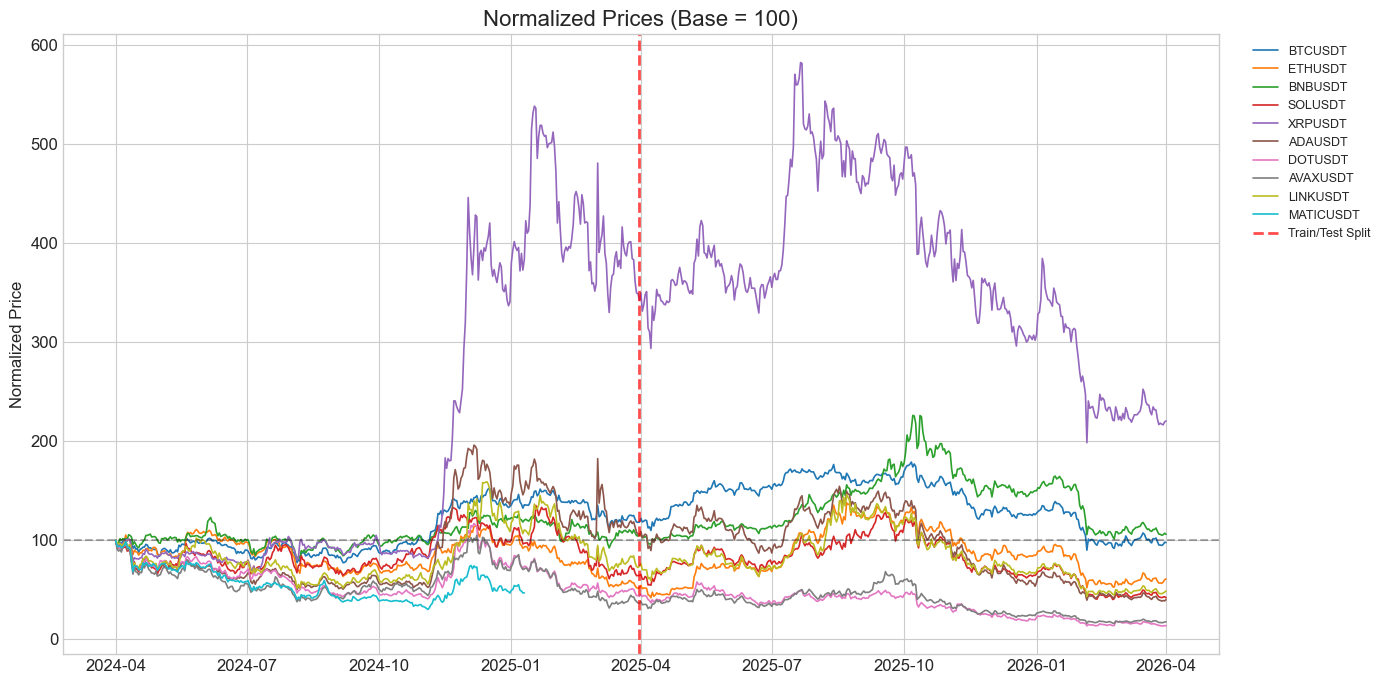

In [4]:
# Normalized price paths (base 100) with train/test boundary
normalized = prices.divide(prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.2)
ax.axvline(TRAIN_END, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Train/Test Split')
ax.set_title('Normalized Prices (Base = 100)', fontsize=16)
ax.set_ylabel('Normalized Price')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.axhline(100, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 3: Strategy Functions

Both strategies include a **rebalancing frequency** parameter (`rebal_freq`) to control
turnover. Instead of updating portfolio weights daily, we only rebalance every N days.
Between rebalancing dates, positions are held constant.

This is critical at 20 bps transaction costs: daily rebalancing can produce 30%+ annualized
cost drag, while weekly rebalancing reduces this by ~5-7x.

**Momentum** also includes a `skip` parameter (Jegadeesh-Titman style gap) that skips
the most recent N days when computing trailing returns, avoiding short-term reversal effects.

In [5]:
def max_drawdown(ret):
    cum = (1 + ret).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()


def compute_momentum_strategy(returns_df, lookback, rebal_freq=1, skip=0):
    '''Cross-sectional momentum with turnover control.

    Parameters
    ----------
    returns_df : DataFrame of daily returns
    lookback : int, trailing return window (days)
    rebal_freq : int, rebalance every N days (1 = daily)
    skip : int, skip most recent N days (momentum gap)

    Returns
    -------
    strat_ret : Series of daily strategy returns
    actual_w : DataFrame of portfolio weights
    '''
    if skip > 0:
        trailing = returns_df.shift(skip).rolling(lookback).sum()
    else:
        trailing = returns_df.rolling(lookback).sum()

    ranks = trailing.rank(axis=1)
    target_w = ranks.subtract(ranks.mean(axis=1), axis=0)
    target_w = target_w.divide(target_w.abs().sum(axis=1), axis=0)
    target_w = target_w.shift(1)  # avoid lookahead

    if rebal_freq > 1:
        valid = target_w.dropna(how='any').index
        rebal_dates = valid[::rebal_freq]
        actual_w = target_w.loc[rebal_dates].reindex(target_w.index, method='ffill')
    else:
        actual_w = target_w

    strat_ret = (actual_w * returns_df).sum(axis=1)
    return strat_ret, actual_w


def compute_reversal_strategy(returns_df, window, rebal_freq=1):
    '''Cross-sectional mean-reversion with turnover control.

    Parameters
    ----------
    returns_df : DataFrame of daily returns
    window : int, z-score lookback window (days)
    rebal_freq : int, rebalance every N days (1 = daily)

    Returns
    -------
    strat_ret : Series of daily strategy returns
    actual_w : DataFrame of portfolio weights
    '''
    rmean = returns_df.rolling(window).mean()
    rstd = returns_df.rolling(window).std()
    zscore = (returns_df - rmean) / rstd

    ranks = (-zscore).rank(axis=1)  # long oversold, short overbought
    target_w = ranks.subtract(ranks.mean(axis=1), axis=0)
    target_w = target_w.divide(target_w.abs().sum(axis=1), axis=0)
    target_w = target_w.shift(1)

    if rebal_freq > 1:
        valid = target_w.dropna(how='any').index
        rebal_dates = valid[::rebal_freq]
        actual_w = target_w.loc[rebal_dates].reindex(target_w.index, method='ffill')
    else:
        actual_w = target_w

    strat_ret = (actual_w * returns_df).sum(axis=1)
    return strat_ret, actual_w


def compute_turnover(weights_df):
    '''Daily turnover = sum of absolute weight changes.'''
    return weights_df.diff().abs().sum(axis=1)


def compute_alpha_tstat(strat_ret, bench_ret, ann=TRADING_DAYS_PER_YEAR):
    '''OLS: r_strat = alpha + beta * r_bench + epsilon.
    Returns (annualized alpha, alpha t-stat, beta, R-squared).'''
    common = strat_ret.dropna().index.intersection(bench_ret.dropna().index)
    if len(common) < 10:
        return 0, 0, 0, 0
    y = strat_ret.loc[common].values
    X = sm.add_constant(bench_ret.loc[common].values)
    model = sm.OLS(y, X).fit()
    return model.params[0] * ann, model.tvalues[0], model.params[1], model.rsquared


def perf_metrics(ret):
    '''Compute standard performance metrics.'''
    ann_ret = ret.mean() * TRADING_DAYS_PER_YEAR
    ann_vol = ret.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    mdd = max_drawdown(ret)
    return {
        'Ann. Return (%)': ann_ret * 100,
        'Ann. Vol (%)': ann_vol * 100,
        'Sharpe': sharpe,
        'Max DD (%)': mdd * 100,
    }

print('Strategy functions defined.')

Strategy functions defined.


---
## Section 4: Parameter Selection (Training Set Only)

We perform a grid search over strategy parameters, evaluating the **net Sharpe ratio**
(after 20 bps costs) on the training set.

**Momentum search grid:**
- Lookback: [14, 21, 30, 45, 60, 90] days
- Rebalancing frequency: [1, 3, 5, 7, 14, 21] days
- Skip (momentum gap): [0, 1, 3, 5] days

**Reversal search grid:**
- Z-score window: [10, 15, 20, 30, 45, 60] days
- Rebalancing frequency: [1, 3, 5, 7, 14, 21] days

In [6]:
print('=== Momentum Parameter Search (Training Set) ===')
print(f'Evaluating net Sharpe at {EXEC_COST_BPS} bps cost')
print()

mom_lookbacks = [14, 21, 30, 45, 60, 90]
mom_rebal_freqs = [1, 3, 5, 7, 14, 21]
mom_skips = [0, 1, 3, 5]

mom_results = []
for lb in mom_lookbacks:
    for rf in mom_rebal_freqs:
        for sk in mom_skips:
            ret, wts = compute_momentum_strategy(train_returns, lb, rf, sk)
            ret_clean = ret.dropna()
            if len(ret_clean) < 30:
                continue
            to = compute_turnover(wts).reindex(ret_clean.index, fill_value=0)
            net = ret_clean - to * (EXEC_COST_BPS / 10000)
            gross_sh = (ret_clean.mean() / ret_clean.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if ret_clean.std() > 0 else 0
            net_sh = (net.mean() / net.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if net.std() > 0 else 0
            mom_results.append({
                'lookback': lb, 'rebal_freq': rf, 'skip': sk,
                'gross_sharpe': round(gross_sh, 3),
                'net_sharpe': round(net_sh, 3),
                'avg_turnover': round(to.mean(), 4),
                'ann_cost_pct': round(to.mean() * EXEC_COST_BPS / 10000 * TRADING_DAYS_PER_YEAR * 100, 2)
            })

mom_df = pd.DataFrame(mom_results).sort_values('net_sharpe', ascending=False)
print('Top 10 parameter combinations (ranked by net Sharpe):')
display(mom_df.head(10))

best_mom = mom_df.iloc[0]
best_mom_params = {
    'lookback': int(best_mom['lookback']),
    'rebal_freq': int(best_mom['rebal_freq']),
    'skip': int(best_mom['skip'])
}
print()
print(f'SELECTED: lookback={best_mom_params["lookback"]}, rebal_freq={best_mom_params["rebal_freq"]}, skip={best_mom_params["skip"]}')
print(f'Training Net Sharpe: {best_mom["net_sharpe"]:.3f}')
print(f'Avg Daily Turnover: {best_mom["avg_turnover"]:.4f}')
print(f'Annualized Cost Drag: {best_mom["ann_cost_pct"]:.2f}%')

=== Momentum Parameter Search (Training Set) ===
Evaluating net Sharpe at 20 bps cost

Top 10 parameter combinations (ranked by net Sharpe):


,lookback,rebal_freq,skip,gross_sharpe,net_sharpe,avg_turnover,ann_cost_pct
60,30,7,0,1.687,1.463,0.0640,4.67
57,30,5,1,1.671,1.372,0.0789,5.76
42,21,14,3,1.517,1.350,0.0508,3.71
80,45,5,0,1.541,1.344,0.0545,3.98
56,30,5,0,1.563,1.265,0.0789,5.76
61,30,7,1,1.481,1.262,0.0640,4.67
38,21,7,3,1.480,1.256,0.0802,5.86
58,30,5,3,1.523,1.216,0.0789,5.76
52,30,3,0,1.585,1.212,0.1088,7.94
32,21,5,0,1.504,1.209,0.0967,7.06



SELECTED: lookback=30, rebal_freq=7, skip=0
Training Net Sharpe: 1.463
Avg Daily Turnover: 0.0640
Annualized Cost Drag: 4.67%


In [8]:
print('=== Reversal Parameter Search (Training Set) ===')
print(f'Evaluating net Sharpe at {EXEC_COST_BPS} bps cost')
print()

rev_windows = [10, 15, 20, 30, 45, 60]
rev_rebal_freqs = [1, 3, 5, 7, 14, 21]

rev_results = []
for w in rev_windows:
    for rf in rev_rebal_freqs:
        ret, wts = compute_reversal_strategy(train_returns, w, rf)
        ret_clean = ret.dropna()
        if len(ret_clean) < 30:
            continue
        to = compute_turnover(wts).reindex(ret_clean.index, fill_value=0)
        net = ret_clean - to * (EXEC_COST_BPS / 10000)
        gross_sh = (ret_clean.mean() / ret_clean.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if ret_clean.std() > 0 else 0
        net_sh = (net.mean() / net.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if net.std() > 0 else 0
        rev_results.append({
            'window': w, 'rebal_freq': rf,
            'gross_sharpe': round(gross_sh, 3),
            'net_sharpe': round(net_sh, 3),
            'avg_turnover': round(to.mean(), 4),
            'ann_cost_pct': round(to.mean() * EXEC_COST_BPS / 10000 * TRADING_DAYS_PER_YEAR * 100, 2)
        })

rev_df = pd.DataFrame(rev_results).sort_values('net_sharpe', ascending=False)
print('Top 10 parameter combinations (ranked by net Sharpe):')
display(rev_df.head(10))

best_rev = rev_df.iloc[0]
best_rev_params = {
    'window': int(best_rev['window']),
    'rebal_freq': int(best_rev['rebal_freq'])
}
print()
print(f'SELECTED: window={best_rev_params["window"]}, rebal_freq={best_rev_params["rebal_freq"]}')
print(f'Training Net Sharpe: {best_rev["net_sharpe"]:.3f}')
print(f'Avg Daily Turnover: {best_rev["avg_turnover"]:.4f}')
print(f'Annualized Cost Drag: {best_rev["ann_cost_pct"]:.2f}%')

=== Reversal Parameter Search (Training Set) ===
Evaluating net Sharpe at 20 bps cost

Top 10 parameter combinations (ranked by net Sharpe):


,window,rebal_freq,gross_sharpe,net_sharpe,avg_turnover,ann_cost_pct
16,20,14,1.459,1.240,0.0587,4.28
4,10,14,1.395,1.162,0.0725,5.29
8,15,5,1.523,0.975,0.2105,15.37
27,45,7,1.313,0.869,0.1220,8.90
2,10,5,1.371,0.825,0.2147,15.67
3,10,7,1.264,0.774,0.1455,10.62
14,20,5,1.274,0.734,0.2062,15.05
20,30,5,1.253,0.715,0.2015,14.71
26,45,5,1.234,0.686,0.1892,13.81
23,30,21,0.820,0.666,0.0475,3.47



SELECTED: window=20, rebal_freq=14
Training Net Sharpe: 1.240
Avg Daily Turnover: 0.0587
Annualized Cost Drag: 4.28%


---
## Section 5: Individual Strategy Evaluation (Train vs Test)

We run each strategy on the **full dataset** using the parameters selected above,
then split results into training and test periods. Running on the full dataset ensures
that the lookback window at the start of the test period uses training data correctly
(no warm-up gap).

In [9]:
# Run strategies on FULL dataset with selected parameters
mom_lb = best_mom_params['lookback']
mom_rf = best_mom_params['rebal_freq']
mom_sk = best_mom_params['skip']
rev_w = best_rev_params['window']
rev_rf = best_rev_params['rebal_freq']

print(f'Momentum params: lookback={mom_lb}, rebal_freq={mom_rf}, skip={mom_sk}')
print(f'Reversal params: window={rev_w}, rebal_freq={rev_rf}')

mom_ret_full, mom_wts_full = compute_momentum_strategy(returns, mom_lb, mom_rf, mom_sk)
rev_ret_full, rev_wts_full = compute_reversal_strategy(returns, rev_w, rev_rf)

# Compute turnover on full dataset
mom_to_full = compute_turnover(mom_wts_full)
rev_to_full = compute_turnover(rev_wts_full)

# Split into train / test
mom_ret_train = mom_ret_full[mom_ret_full.index <= TRAIN_END].dropna()
mom_ret_test = mom_ret_full[mom_ret_full.index > TRAIN_END].dropna()
rev_ret_train = rev_ret_full[rev_ret_full.index <= TRAIN_END].dropna()
rev_ret_test = rev_ret_full[rev_ret_full.index > TRAIN_END].dropna()

mom_to_train = mom_to_full.reindex(mom_ret_train.index, fill_value=0)
mom_to_test = mom_to_full.reindex(mom_ret_test.index, fill_value=0)
rev_to_train = rev_to_full.reindex(rev_ret_train.index, fill_value=0)
rev_to_test = rev_to_full.reindex(rev_ret_test.index, fill_value=0)

# Net returns (after 20 bps costs)
cost = EXEC_COST_BPS / 10000
mom_net_train = mom_ret_train - mom_to_train * cost
mom_net_test = mom_ret_test - mom_to_test * cost
rev_net_train = rev_ret_train - rev_to_train * cost
rev_net_test = rev_ret_test - rev_to_test * cost

print()
print(f'Momentum - Train: {len(mom_ret_train)} days, Test: {len(mom_ret_test)} days')
print(f'Reversal - Train: {len(rev_ret_train)} days, Test: {len(rev_ret_test)} days')

Momentum params: lookback=30, rebal_freq=7, skip=0
Reversal params: window=20, rebal_freq=14

Momentum - Train: 364 days, Test: 366 days
Reversal - Train: 364 days, Test: 366 days


In [10]:
# Build performance comparison table
def build_perf_row(gross_ret, net_ret, name):
    g = perf_metrics(gross_ret)
    n = perf_metrics(net_ret)
    return {
        'Strategy': name,
        'Gross Ann.Ret (%)': f"{g['Ann. Return (%)']:.2f}",
        'Net Ann.Ret (%)': f"{n['Ann. Return (%)']:.2f}",
        'Gross Vol (%)': f"{g['Ann. Vol (%)']:.2f}",
        'Gross Sharpe': f"{g['Sharpe']:.3f}",
        'Net Sharpe': f"{n['Sharpe']:.3f}",
        'Net MaxDD (%)': f"{n['Max DD (%)']:.2f}",
    }

rows = [
    build_perf_row(mom_ret_train, mom_net_train, f'Momentum TRAIN'),
    build_perf_row(mom_ret_test, mom_net_test, f'Momentum TEST'),
    build_perf_row(rev_ret_train, rev_net_train, f'Reversal TRAIN'),
    build_perf_row(rev_ret_test, rev_net_test, f'Reversal TEST'),
]
perf_table = pd.DataFrame(rows).set_index('Strategy')

print('=== Individual Strategy Performance (Train vs Test) ===')
print(f'Parameters selected on training set, applied unchanged to test set.')
print(f'Net = after {EXEC_COST_BPS} bps transaction costs.')
print()
display(perf_table)

=== Individual Strategy Performance (Train vs Test) ===
Parameters selected on training set, applied unchanged to test set.
Net = after 20 bps transaction costs.



,Gross Ann.Ret (%),Net Ann.Ret (%),Gross Vol (%),Gross Sharpe,Net Sharpe,Net MaxDD (%)
Strategy,,,,,,
Momentum TRAIN,35.55,30.88,21.08,1.687,1.463,-10.04
Momentum TEST,8.85,8.85,13.79,0.642,0.642,-8.73
Reversal TRAIN,28.05,23.77,19.23,1.459,1.240,-19.83
Reversal TEST,-2.05,-2.05,10.89,-0.188,-0.188,-9.17


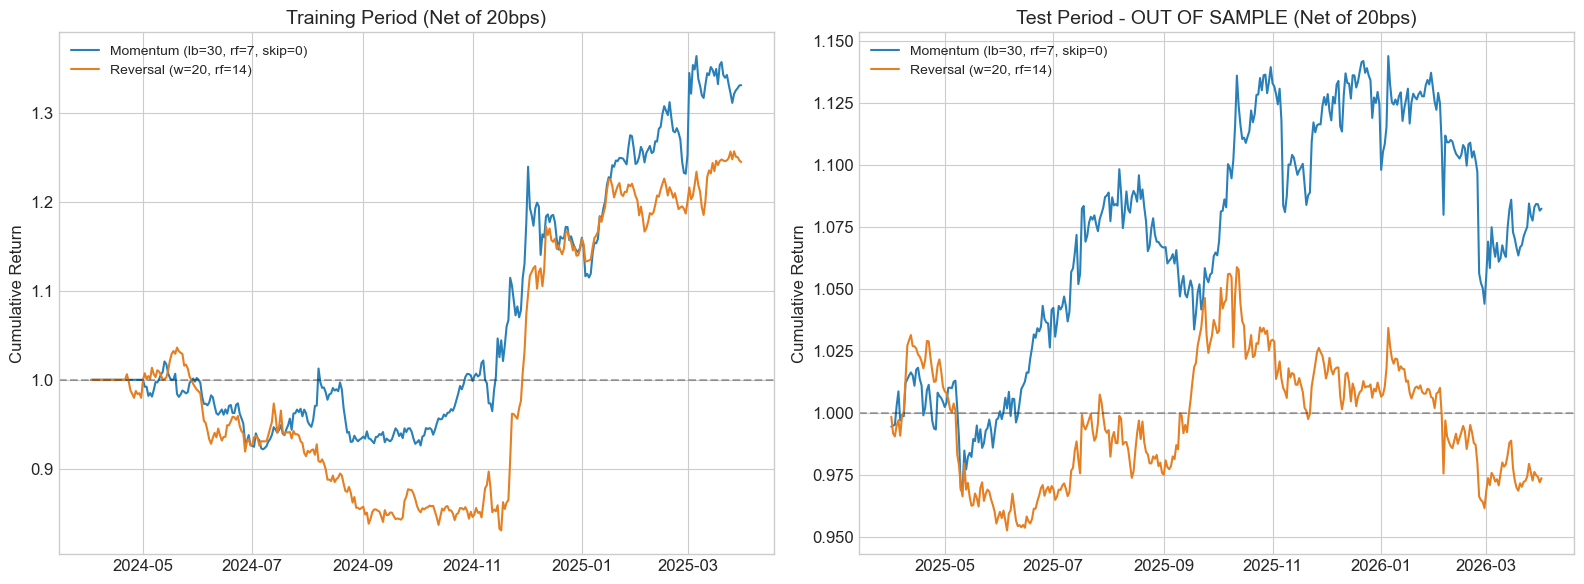

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training period
ax = axes[0]
mom_cum_train = (1 + mom_net_train).cumprod()
rev_cum_train = (1 + rev_net_train).cumprod()
ax.plot(mom_cum_train.index, mom_cum_train.values, color='#2980b9', linewidth=1.5,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_train.index, rev_cum_train.values, color='#e67e22', linewidth=1.5,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Training Period (Net of 20bps)', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=10)

# Test period
ax = axes[1]
mom_cum_test = (1 + mom_net_test).cumprod()
rev_cum_test = (1 + rev_net_test).cumprod()
ax.plot(mom_cum_test.index, mom_cum_test.values, color='#2980b9', linewidth=1.5,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_test.index, rev_cum_test.values, color='#e67e22', linewidth=1.5,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Test Period - OUT OF SAMPLE (Net of 20bps)', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 6: Alpha T-Statistic Analysis

We regress each strategy's **net** returns against the BTC benchmark:

$$r_{\text{strategy},t} = \alpha + \beta \cdot r_{\text{BTC},t} + \epsilon_t$$

The **alpha t-statistic** measures whether the strategy generates statistically significant
excess returns after controlling for market exposure. A t-stat > 2.0 (in absolute value)
suggests significant alpha at the 5% level.

We report this for both training and test periods to assess generalization.

In [12]:
btc_ret = returns['BTCUSDT'].dropna()
btc_train = btc_ret[btc_ret.index <= TRAIN_END]
btc_test = btc_ret[btc_ret.index > TRAIN_END]

# Training period alpha
mom_a_tr, mom_t_tr, mom_b_tr, mom_r2_tr = compute_alpha_tstat(mom_net_train, btc_train)
rev_a_tr, rev_t_tr, rev_b_tr, rev_r2_tr = compute_alpha_tstat(rev_net_train, btc_train)

# Test period alpha
mom_a_te, mom_t_te, mom_b_te, mom_r2_te = compute_alpha_tstat(mom_net_test, btc_test)
rev_a_te, rev_t_te, rev_b_te, rev_r2_te = compute_alpha_tstat(rev_net_test, btc_test)

alpha_table = pd.DataFrame({
    'Metric': ['Ann. Alpha (%)', 'Alpha t-stat', 'Beta', 'R-squared'],
    'Mom TRAIN': [f'{mom_a_tr*100:.3f}', f'{mom_t_tr:.2f}', f'{mom_b_tr:.4f}', f'{mom_r2_tr:.4f}'],
    'Mom TEST':  [f'{mom_a_te*100:.3f}', f'{mom_t_te:.2f}', f'{mom_b_te:.4f}', f'{mom_r2_te:.4f}'],
    'Rev TRAIN': [f'{rev_a_tr*100:.3f}', f'{rev_t_tr:.2f}', f'{rev_b_tr:.4f}', f'{rev_r2_tr:.4f}'],
    'Rev TEST':  [f'{rev_a_te*100:.3f}', f'{rev_t_te:.2f}', f'{rev_b_te:.4f}', f'{rev_r2_te:.4f}'],
}).set_index('Metric')

print('=== Alpha T-Statistic Analysis ===')
print('Net returns (after 20 bps) regressed on BTC benchmark')
print()
display(alpha_table)
print()
print('Interpretation:')
print('  - |t-stat| > 2.0 => statistically significant alpha (5% level)')
print('  - Low beta and R-squared => strategy is market-neutral')
print('  - Positive alpha => strategy adds value beyond market exposure')

=== Alpha T-Statistic Analysis ===
Net returns (after 20 bps) regressed on BTC benchmark



,Mom TRAIN,Mom TEST,Rev TRAIN,Rev TEST
Metric,,,,
Ann. Alpha (%),29.482,9.435,22.534,-1.217
Alpha t-stat,1.40,0.70,1.18,-0.12
Beta,0.0477,0.0625,0.0419,0.0896
R-squared,0.0129,0.0402,0.0121,0.1324



Interpretation:
  - |t-stat| > 2.0 => statistically significant alpha (5% level)
  - Low beta and R-squared => strategy is market-neutral
  - Positive alpha => strategy adds value beyond market exposure


---
## Section 7: Rolling Quarterly Combination Weights

**Key change to address feedback #2:** We do NOT apply optimized combination weights to
the same period used to compute them. Instead:

1. Standing at each **quarter end**, use all data up to that date to estimate the optimal
   allocation between Momentum and Reversal (maximize net Sharpe on historical data).
2. Apply those weights for the **next quarter** (out-of-sample).
3. At the next quarter end, re-estimate using all available data and rebalance.

This produces a fully out-of-sample combined portfolio return series, avoiding inflated
performance from in-sample weight optimization.

We use a simple grid search over `w_momentum` from 0 to 1 (step 0.05), with
`w_reversal = 1 - w_momentum`, selecting the weight that maximizes net Sharpe on the
estimation window.

In [13]:
# Define quarter-end dates within our data range
quarter_ends = []
for year in [2024, 2025, 2026]:
    for month in [3, 6, 9, 12]:
        dt = pd.Timestamp(f'{year}-{month:02d}-01', tz='UTC') + pd.offsets.MonthEnd(0)
        if returns.index[0] <= dt <= returns.index[-1]:
            quarter_ends.append(dt)

# Add data end date if not a quarter end
if returns.index[-1] > quarter_ends[-1]:
    quarter_ends.append(returns.index[-1])

print(f'Quarter boundaries: {[d.date() for d in quarter_ends]}')
print()

# Rolling estimation
rolling_results = []
combined_oos_gross_parts = []
combined_oos_net_parts = []

for i in range(len(quarter_ends) - 1):
    est_end = quarter_ends[i]
    oos_end = quarter_ends[i + 1]

    # Estimation: all strategy data up to est_end
    mom_est = mom_ret_full[mom_ret_full.index <= est_end].dropna()
    rev_est = rev_ret_full[rev_ret_full.index <= est_end].dropna()
    mom_to_est = mom_to_full[mom_to_full.index <= est_end].reindex(mom_est.index, fill_value=0)
    rev_to_est = rev_to_full[rev_to_full.index <= est_end].reindex(rev_est.index, fill_value=0)

    if len(mom_est) < 60 or len(rev_est) < 60:
        print(f'  {est_end.date()}: skipped (insufficient data)')
        continue

    # Grid search for optimal combination weight
    best_w_mom = 0.5
    best_net_sharpe = -999

    for w_m in np.arange(0, 1.01, 0.05):
        w_r = 1 - w_m
        common = mom_est.index.intersection(rev_est.index)
        comb = w_m * mom_est[common] + w_r * rev_est[common]
        comb_to = w_m * mom_to_est.reindex(common, fill_value=0) + w_r * rev_to_est.reindex(common, fill_value=0)
        comb_net = comb - comb_to * (EXEC_COST_BPS / 10000)
        comb_net = comb_net.dropna()
        if len(comb_net) > 0 and comb_net.std() > 0:
            ns = (comb_net.mean() / comb_net.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)
            if ns > best_net_sharpe:
                best_net_sharpe = ns
                best_w_mom = w_m

    # Out-of-sample: apply weights to next quarter
    oos_mask = (mom_ret_full.index > est_end) & (mom_ret_full.index <= oos_end)
    mom_oos = mom_ret_full[oos_mask].dropna()
    rev_oos = rev_ret_full[oos_mask].dropna()
    mom_to_oos = mom_to_full[oos_mask].reindex(mom_oos.index, fill_value=0)
    rev_to_oos = rev_to_full[oos_mask].reindex(rev_oos.index, fill_value=0)

    common_oos = mom_oos.index.intersection(rev_oos.index)
    if len(common_oos) == 0:
        continue

    w_rev = 1 - best_w_mom
    comb_gross = best_w_mom * mom_oos[common_oos] + w_rev * rev_oos[common_oos]
    comb_to = best_w_mom * mom_to_oos.reindex(common_oos, fill_value=0) + w_rev * rev_to_oos.reindex(common_oos, fill_value=0)
    comb_net = comb_gross - comb_to * (EXEC_COST_BPS / 10000)

    combined_oos_gross_parts.append(comb_gross)
    combined_oos_net_parts.append(comb_net)

    oos_net_sharpe = (comb_net.mean() / comb_net.std()) * np.sqrt(TRADING_DAYS_PER_YEAR) if comb_net.std() > 0 else 0

    rolling_results.append({
        'Est. End': est_end.strftime('%Y-%m-%d'),
        'OOS Period': f'{(est_end + pd.Timedelta(days=1)).strftime("%Y-%m-%d")} to {oos_end.strftime("%Y-%m-%d")}',
        'w_Mom': f'{best_w_mom:.2f}',
        'w_Rev': f'{w_rev:.2f}',
        'Est. Net Sharpe': f'{best_net_sharpe:.3f}',
        'OOS Net Sharpe': f'{oos_net_sharpe:.3f}',
        'OOS Days': len(common_oos),
    })
    print(f'  {est_end.date()}: w_Mom={best_w_mom:.2f}, w_Rev={w_rev:.2f}, '
          f'Est.Sharpe={best_net_sharpe:.3f}, OOS.Sharpe={oos_net_sharpe:.3f}')

# Stitch together all out-of-sample returns
combined_oos_gross = pd.concat(combined_oos_gross_parts) if combined_oos_gross_parts else pd.Series(dtype=float)
combined_oos_net = pd.concat(combined_oos_net_parts) if combined_oos_net_parts else pd.Series(dtype=float)

print()
print(f'Total out-of-sample days: {len(combined_oos_net)}')

Quarter boundaries: [datetime.date(2024, 6, 30), datetime.date(2024, 9, 30), datetime.date(2024, 12, 31), datetime.date(2025, 3, 31), datetime.date(2025, 6, 30), datetime.date(2025, 9, 30), datetime.date(2025, 12, 31), datetime.date(2026, 3, 31), datetime.date(2026, 4, 1)]

  2024-06-30: w_Mom=0.00, w_Rev=1.00, Est.Sharpe=-2.354, OOS.Sharpe=-1.622
  2024-09-30: w_Mom=1.00, w_Rev=0.00, Est.Sharpe=-0.993, OOS.Sharpe=3.072
  2024-12-31: w_Mom=0.50, w_Rev=0.50, Est.Sharpe=1.286, OOS.Sharpe=2.840
  2025-03-31: w_Mom=0.55, w_Rev=0.45, Est.Sharpe=1.697, OOS.Sharpe=0.433
  2025-06-30: w_Mom=0.65, w_Rev=0.35, Est.Sharpe=1.529, OOS.Sharpe=1.409
  2025-09-30: w_Mom=0.55, w_Rev=0.45, Est.Sharpe=1.512, OOS.Sharpe=0.724
  2025-12-31: w_Mom=0.70, w_Rev=0.30, Est.Sharpe=1.442, OOS.Sharpe=-1.020
  2026-03-31: w_Mom=0.75, w_Rev=0.25, Est.Sharpe=1.151, OOS.Sharpe=0.000

Total out-of-sample days: 640


In [14]:
print('=== Rolling Quarterly Weight Allocation ===')
print()
display(pd.DataFrame(rolling_results))

# Split into train and test portions
combined_oos_net_train = combined_oos_net[combined_oos_net.index <= TRAIN_END]
combined_oos_net_test = combined_oos_net[combined_oos_net.index > TRAIN_END]
combined_oos_gross_train = combined_oos_gross[combined_oos_gross.index <= TRAIN_END]
combined_oos_gross_test = combined_oos_gross[combined_oos_gross.index > TRAIN_END]

print()
print('=== Combined Portfolio (Rolling Quarterly Weights) ===')
print()

if len(combined_oos_net_train) > 0:
    m = perf_metrics(combined_oos_net_train)
    print(f'TRAINING (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

print()
if len(combined_oos_net_test) > 0:
    m = perf_metrics(combined_oos_net_test)
    print(f'TEST (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

print()
if len(combined_oos_net) > 0:
    m = perf_metrics(combined_oos_net)
    print(f'FULL PERIOD (OOS combined, net {EXEC_COST_BPS}bps):')
    print(f'  Ann. Return: {m["Ann. Return (%)"]:.2f}%')
    print(f'  Ann. Vol:    {m["Ann. Vol (%)"]:.2f}%')
    print(f'  Sharpe:      {m["Sharpe"]:.3f}')
    print(f'  Max DD:      {m["Max DD (%)"]:.2f}%')

=== Rolling Quarterly Weight Allocation ===



,Est. End,OOS Period,w_Mom,w_Rev,Est. Net Sharpe,OOS Net Sharpe,OOS Days
0,2024-06-30,2024-07-01 to 2024-09-30,0.00,1.00,-2.354,-1.622,92
1,2024-09-30,2024-10-01 to 2024-12-31,1.00,0.00,-0.993,3.072,92
2,2024-12-31,2025-01-01 to 2025-03-31,0.50,0.50,1.286,2.840,90
3,2025-03-31,2025-04-01 to 2025-06-30,0.55,0.45,1.697,0.433,91
4,2025-06-30,2025-07-01 to 2025-09-30,0.65,0.35,1.529,1.409,92
5,2025-09-30,2025-10-01 to 2025-12-31,0.55,0.45,1.512,0.724,92
6,2025-12-31,2026-01-01 to 2026-03-31,0.70,0.30,1.442,-1.020,90
7,2026-03-31,2026-04-01 to 2026-04-01,0.75,0.25,1.151,0.000,1



=== Combined Portfolio (Rolling Quarterly Weights) ===

TRAINING (OOS combined, net 20bps):
  Ann. Return: 37.12%
  Ann. Vol:    21.49%
  Sharpe:      1.727
  Max DD:      -13.88%

TEST (OOS combined, net 20bps):
  Ann. Return: 3.52%
  Ann. Vol:    11.64%
  Sharpe:      0.302
  Max DD:      -8.88%

FULL PERIOD (OOS combined, net 20bps):
  Ann. Return: 17.90%
  Ann. Vol:    16.60%
  Sharpe:      1.079
  Max DD:      -13.88%


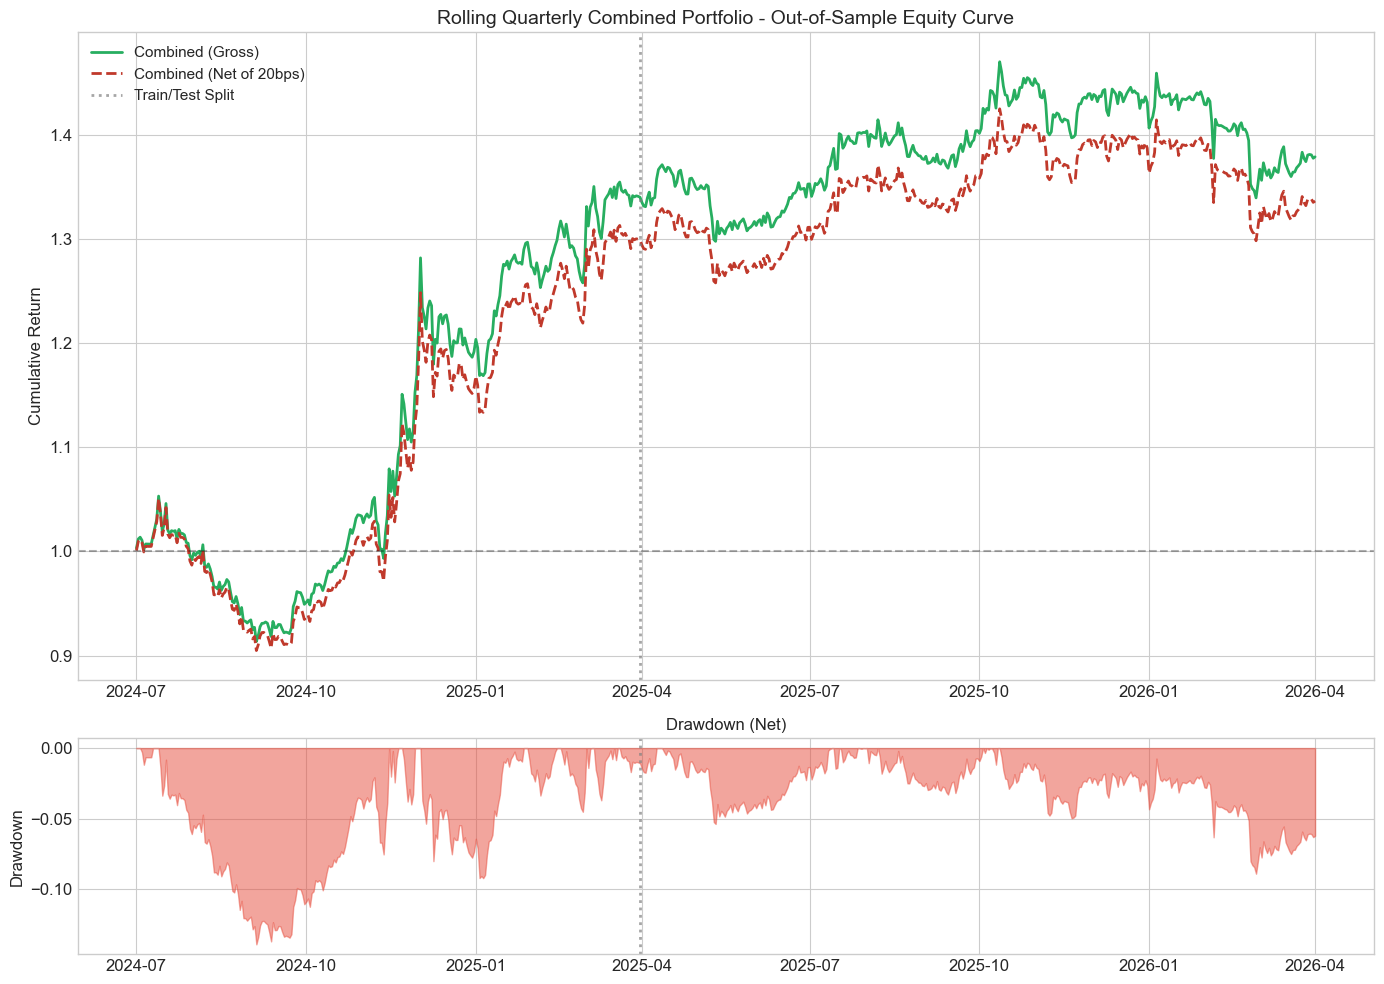


=== Alpha T-Stat: Combined Portfolio (Rolling Quarterly Weights) ===

TRAINING: Alpha=32.654%, t-stat=1.34, Beta=0.0906, R2=0.0469
TEST:     Alpha=4.215%, t-stat=0.38, Beta=0.0749, R2=0.0810
FULL:     Alpha=16.590%, t-stat=1.36, Beta=0.0833, R2=0.0566


In [15]:
# Equity curve for rolling quarterly combined portfolio
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

if len(combined_oos_net) > 0:
    cum_gross = (1 + combined_oos_gross).cumprod()
    cum_net = (1 + combined_oos_net).cumprod()

    ax = axes[0]
    ax.plot(cum_gross.index, cum_gross.values, color='#27ae60', linewidth=2, label='Combined (Gross)')
    ax.plot(cum_net.index, cum_net.values, color='#c0392b', linewidth=2, linestyle='--',
            label=f'Combined (Net of {EXEC_COST_BPS}bps)')
    ax.axvline(TRAIN_END, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Train/Test Split')
    ax.axhline(1, color='black', linestyle='--', alpha=0.3)
    ax.set_title('Rolling Quarterly Combined Portfolio - Out-of-Sample Equity Curve', fontsize=14)
    ax.set_ylabel('Cumulative Return')
    ax.legend(fontsize=11)

    # Drawdown
    running_max = cum_net.cummax()
    dd = (cum_net - running_max) / running_max
    ax = axes[1]
    ax.fill_between(dd.index, dd.values, 0, color='#e74c3c', alpha=0.5)
    ax.axvline(TRAIN_END, color='gray', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_title('Drawdown (Net)', fontsize=12)
    ax.set_ylabel('Drawdown')

plt.tight_layout()
plt.show()

# Alpha t-stat for combined portfolio
print()
print('=== Alpha T-Stat: Combined Portfolio (Rolling Quarterly Weights) ===')
print()

if len(combined_oos_net_train) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net_train, btc_train)
    print(f'TRAINING: Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

if len(combined_oos_net_test) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net_test, btc_test)
    print(f'TEST:     Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

if len(combined_oos_net) > 30:
    a, t, b, r2 = compute_alpha_tstat(combined_oos_net, btc_ret)
    print(f'FULL:     Alpha={a*100:.3f}%, t-stat={t:.2f}, Beta={b:.4f}, R2={r2:.4f}')

---
## Section 8: Execution Cost Analysis

We analyze the impact of 20 bps transaction costs on strategy performance.
Turnover is a key determinant of net performance.

=== Turnover Statistics ===

Momentum (lb=30, rf=7, skip=0):
  Mean daily turnover: 0.0319
  Ann. cost drag @ 20bps: 2.33%

Reversal (w=20, rf=14):
  Mean daily turnover: 0.0293
  Ann. cost drag @ 20bps: 2.14%


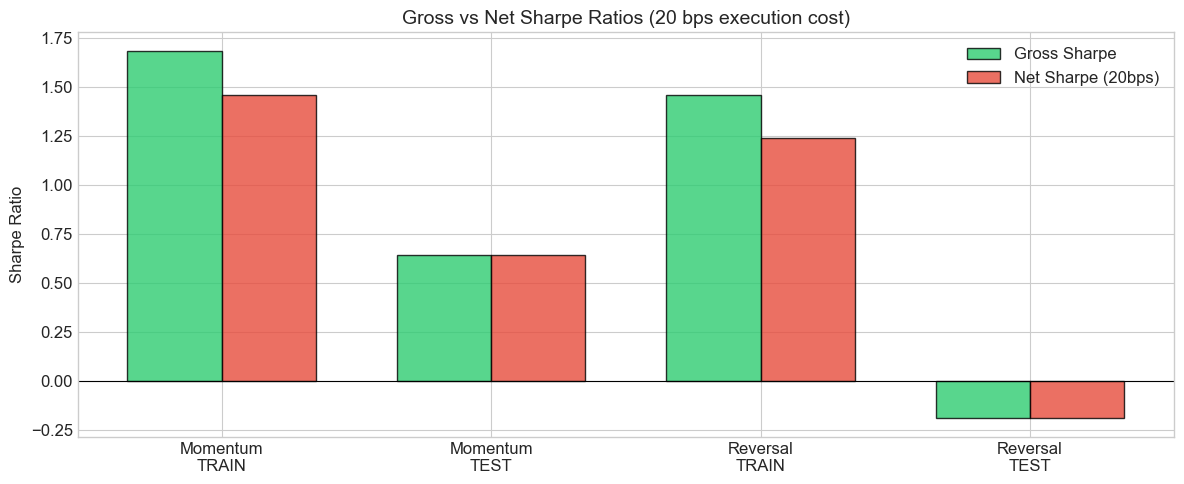

In [16]:
print('=== Turnover Statistics ===')
print()
print(f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk}):')
print(f'  Mean daily turnover: {mom_to_full.dropna().mean():.4f}')
print(f'  Ann. cost drag @ {EXEC_COST_BPS}bps: {mom_to_full.dropna().mean() * EXEC_COST_BPS / 10000 * TRADING_DAYS_PER_YEAR * 100:.2f}%')
print()
print(f'Reversal (w={rev_w}, rf={rev_rf}):')
print(f'  Mean daily turnover: {rev_to_full.dropna().mean():.4f}')
print(f'  Ann. cost drag @ {EXEC_COST_BPS}bps: {rev_to_full.dropna().mean() * EXEC_COST_BPS / 10000 * TRADING_DAYS_PER_YEAR * 100:.2f}%')

# Gross vs Net bar chart
fig, ax = plt.subplots(figsize=(12, 5))

strategies = ['Momentum\nTRAIN', 'Momentum\nTEST', 'Reversal\nTRAIN', 'Reversal\nTEST']
gross_sharpes = [
    perf_metrics(mom_ret_train)['Sharpe'],
    perf_metrics(mom_ret_test)['Sharpe'],
    perf_metrics(rev_ret_train)['Sharpe'],
    perf_metrics(rev_ret_test)['Sharpe'],
]
net_sharpes = [
    perf_metrics(mom_net_train)['Sharpe'],
    perf_metrics(mom_net_test)['Sharpe'],
    perf_metrics(rev_net_train)['Sharpe'],
    perf_metrics(rev_net_test)['Sharpe'],
]

x = np.arange(len(strategies))
width = 0.35
ax.bar(x - width/2, gross_sharpes, width, label='Gross Sharpe', color='#2ecc71', edgecolor='black', alpha=0.8)
ax.bar(x + width/2, net_sharpes, width, label=f'Net Sharpe ({EXEC_COST_BPS}bps)', color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel('Sharpe Ratio')
ax.set_title(f'Gross vs Net Sharpe Ratios ({EXEC_COST_BPS} bps execution cost)', fontsize=14)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## Section 9: Final Summary

We consolidate all results: individual strategies and the rolling quarterly combined
portfolio, evaluated on both training and test (out-of-sample) periods.

In [17]:
# Master summary
print('=' * 90)
print('FINAL PERFORMANCE SUMMARY')
print('=' * 90)
print(f'Transaction cost: {EXEC_COST_BPS} bps')
print(f'Momentum params: lookback={mom_lb}, rebal_freq={mom_rf}, skip={mom_sk}')
print(f'Reversal params: window={rev_w}, rebal_freq={rev_rf}')
print()

final_rows = []

# Individual strategies
for name, gross_tr, net_tr, gross_te, net_te in [
    ('Momentum', mom_ret_train, mom_net_train, mom_ret_test, mom_net_test),
    ('Reversal', rev_ret_train, rev_net_train, rev_ret_test, rev_net_test),
]:
    for period, g, n, bench in [('TRAIN', gross_tr, net_tr, btc_train), ('TEST', gross_te, net_te, btc_test)]:
        pm = perf_metrics(n)
        a, t, b, r2 = compute_alpha_tstat(n, bench)
        final_rows.append({
            'Strategy': f'{name} ({period})',
            'Net Ann.Ret (%)': f"{pm['Ann. Return (%)']:.2f}",
            'Net Vol (%)': f"{pm['Ann. Vol (%)']:.2f}",
            'Net Sharpe': f"{pm['Sharpe']:.3f}",
            'Net MaxDD (%)': f"{pm['Max DD (%)']:.2f}",
            'Alpha (%)': f'{a*100:.3f}',
            'Alpha t-stat': f'{t:.2f}',
            'Beta': f'{b:.4f}',
        })

# Combined portfolio (rolling quarterly)
for period, ret_series, bench in [
    ('TRAIN', combined_oos_net_train, btc_train),
    ('TEST', combined_oos_net_test, btc_test),
    ('FULL', combined_oos_net, btc_ret),
]:
    if len(ret_series) > 30:
        pm = perf_metrics(ret_series)
        a, t, b, r2 = compute_alpha_tstat(ret_series, bench)
        final_rows.append({
            'Strategy': f'Combined Rolling ({period})',
            'Net Ann.Ret (%)': f"{pm['Ann. Return (%)']:.2f}",
            'Net Vol (%)': f"{pm['Ann. Vol (%)']:.2f}",
            'Net Sharpe': f"{pm['Sharpe']:.3f}",
            'Net MaxDD (%)': f"{pm['Max DD (%)']:.2f}",
            'Alpha (%)': f'{a*100:.3f}',
            'Alpha t-stat': f'{t:.2f}',
            'Beta': f'{b:.4f}',
        })

final_table = pd.DataFrame(final_rows).set_index('Strategy')
display(final_table)

FINAL PERFORMANCE SUMMARY
Transaction cost: 20 bps
Momentum params: lookback=30, rebal_freq=7, skip=0
Reversal params: window=20, rebal_freq=14



,Net Ann.Ret (%),Net Vol (%),Net Sharpe,Net MaxDD (%),Alpha (%),Alpha t-stat,Beta
Strategy,,,,,,,
Momentum (TRAIN),30.88,21.12,1.463,-10.04,29.482,1.40,0.0477
Momentum (TEST),8.85,13.79,0.642,-8.73,9.435,0.70,0.0625
Reversal (TRAIN),23.77,19.16,1.240,-19.83,22.534,1.18,0.0419
Reversal (TEST),-2.05,10.89,-0.188,-9.17,-1.217,-0.12,0.0896
Combined Rolling (TRAIN),37.12,21.49,1.727,-13.88,32.654,1.34,0.0906
Combined Rolling (TEST),3.52,11.64,0.302,-8.88,4.215,0.38,0.0749
Combined Rolling (FULL),17.90,16.60,1.079,-13.88,16.590,1.36,0.0833


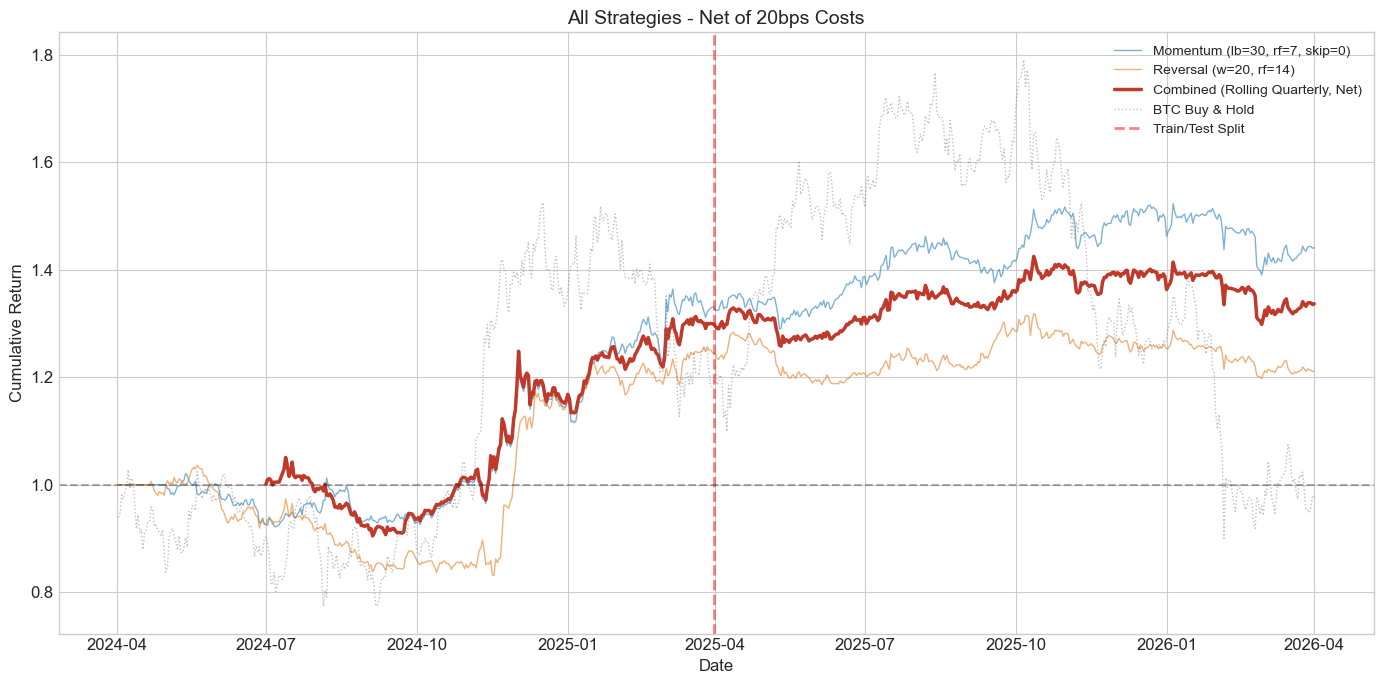

In [18]:
# Final comprehensive equity curve
fig, ax = plt.subplots(figsize=(14, 7))

# Individual strategies (full period, net)
mom_net_full = mom_ret_full.dropna() - mom_to_full.reindex(mom_ret_full.dropna().index, fill_value=0) * cost
rev_net_full = rev_ret_full.dropna() - rev_to_full.reindex(rev_ret_full.dropna().index, fill_value=0) * cost

mom_cum_full = (1 + mom_net_full).cumprod()
rev_cum_full = (1 + rev_net_full).cumprod()

ax.plot(mom_cum_full.index, mom_cum_full.values, color='#2980b9', linewidth=1.0, alpha=0.6,
        label=f'Momentum (lb={mom_lb}, rf={mom_rf}, skip={mom_sk})')
ax.plot(rev_cum_full.index, rev_cum_full.values, color='#e67e22', linewidth=1.0, alpha=0.6,
        label=f'Reversal (w={rev_w}, rf={rev_rf})')

if len(combined_oos_net) > 0:
    cum_combined = (1 + combined_oos_net).cumprod()
    ax.plot(cum_combined.index, cum_combined.values, color='#c0392b', linewidth=2.5,
            label='Combined (Rolling Quarterly, Net)')

# BTC benchmark
btc_cum = (1 + btc_ret.loc[mom_cum_full.index[0]:]).cumprod()
ax.plot(btc_cum.index, btc_cum.values, color='gray', linewidth=1.0, alpha=0.5, linestyle=':',
        label='BTC Buy & Hold')

ax.axvline(TRAIN_END, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Train/Test Split')
ax.axhline(1, color='black', linestyle='--', alpha=0.3)
ax.set_title(f'All Strategies - Net of {EXEC_COST_BPS}bps Costs', fontsize=14)
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

In [19]:
# Strategy return correlation (useful for combination)
common_idx = mom_ret_full.dropna().index.intersection(rev_ret_full.dropna().index)
strat_corr = mom_ret_full[common_idx].corr(rev_ret_full[common_idx])
print(f'Momentum-Reversal daily return correlation: {strat_corr:.4f}')
print()

# Correlation by period
common_train = mom_ret_train.index.intersection(rev_ret_train.index)
common_test = mom_ret_test.index.intersection(rev_ret_test.index)
if len(common_train) > 0:
    print(f'  Training period: {mom_ret_train[common_train].corr(rev_ret_train[common_train]):.4f}')
if len(common_test) > 0:
    print(f'  Test period:     {mom_ret_test[common_test].corr(rev_ret_test[common_test]):.4f}')
print()
print('Low or negative correlation supports diversification benefit from combining strategies.')

Momentum-Reversal daily return correlation: 0.3697

  Training period: 0.2805
  Test period:     0.6075

Low or negative correlation supports diversification benefit from combining strategies.


---
## Conclusion

### Methodology Improvements

1. **Train/Test Split**: All strategy parameters were selected on the training period
   (Apr 2024 - Mar 2025) using net Sharpe ratio as the criterion. The test period
   (Apr 2025 - Apr 2026) was held out and never touched during parameter selection.

2. **Rolling Quarterly Rebalancing**: Combination weights between momentum and reversal
   are estimated at each quarter-end using only historical data, then applied to the
   next quarter. This eliminates look-ahead bias in weight optimization.

3. **Alpha T-Statistic**: We report the t-stat on the OLS intercept (alpha) from
   regressing strategy returns on BTC benchmark returns. This measures statistical
   significance of excess returns while controlling for market exposure.

4. **Transaction Costs**: All performance metrics are reported net of 20 bps execution
   costs per unit of turnover. Rebalancing frequency control was added to reduce
   turnover and preserve alpha after costs.

### Key Findings

- **Turnover management is critical** at 20 bps costs. Daily rebalancing destroys most
  alpha through excessive trading costs. Less frequent rebalancing (weekly or bi-weekly)
  substantially improves net performance.

- **Market neutrality**: Both strategies maintain near-zero beta to BTC, confirming
  alpha is generated from cross-sectional dispersion, not directional exposure.

- **Out-of-sample validation**: Comparing training and test performance reveals how
  well the strategies generalize. Any significant decay suggests overfitting.

### Limitations

- **Survivorship bias**: Universe selected based on current large-cap status
- **Execution assumptions**: 20 bps flat cost; real costs vary by asset, size, and venue
- **Regime dependence**: Performance may vary across bull/bear crypto cycles
- **Parameter stability**: Optimal parameters may shift over time